# Project Mini AlphaZero Lite on TicTacToe (Self-Play + Policy/Value)

This notebook is a **simplified** but very intuitive version of AlphaZero:

- **self-play** to generate data
- a network with **2 heads**:

- **policy head**: probability of action

- **value head**: estimate of state value
- use a **very slight policy improvement** (not full MCTS) to create a better target policy than the original policy

Objectives:

1. Agent learns from itself.

2. Monitor initial/mid/final checkpoints.

3. Evaluate using **100 games** vs random and weak heuristics.

4. Visualize:

- Self-play win signal / draw rate

- Policy loss / value loss

- Action heatmap in some sample states

- Value estimate in sample boards

- Replay of some sample matches

In [1]:

import copy
import random
from collections import defaultdict, deque
from dataclasses import dataclass

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import trange

import torch
import torch.nn as nn
import torch.nn.functional as F

sns.set_context("notebook")
SEED = 123
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


## 1) TicTacToe environment and baseline opponents

In [2]:

WIN_LINES = [
    (0, 1, 2), (3, 4, 5), (6, 7, 8),
    (0, 3, 6), (1, 4, 7), (2, 5, 8),
    (0, 4, 8), (2, 4, 6)
]

class TicTacToeEnv:
    def __init__(self):
        self.reset()

    def reset(self):
        self.board = np.zeros(9, dtype=np.int8)
        self.current_player = 1
        self.done = False
        self.winner = 0
        return self._get_obs(self.current_player)

    def clone(self):
        new_env = TicTacToeEnv()
        new_env.board = self.board.copy()
        new_env.current_player = self.current_player
        new_env.done = self.done
        new_env.winner = self.winner
        return new_env

    def _get_obs(self, player):
        return (self.board * player).astype(np.float32)

    def legal_actions(self):
        return np.where(self.board == 0)[0].tolist()

    def check_winner(self):
        for a, b, c in WIN_LINES:
            s = self.board[a] + self.board[b] + self.board[c]
            if s == 3:
                return 1
            if s == -3:
                return -1
        if np.all(self.board != 0):
            return 0
        return None

    def step(self, action):
        if self.done:
            raise ValueError("Game already finished.")
        if self.board[action] != 0:
            self.done = True
            self.winner = -self.current_player
            reward = -1.0
            return self._get_obs(self.current_player), reward, True, {"invalid": True}

        player = self.current_player
        self.board[action] = player
        result = self.check_winner()
        if result is not None:
            self.done = True
            self.winner = result
            reward = 1.0 if result == player else (0.0 if result == 0 else -1.0)
            return self._get_obs(player), reward, True, {"invalid": False}

        self.current_player *= -1
        return self._get_obs(self.current_player), 0.0, False, {"invalid": False}


def render_board(board):
    symbols = {1: "X", -1: "O", 0: "."}
    rows = []
    for i in range(0, 9, 3):
        rows.append(" ".join(symbols[int(v)] for v in board[i:i+3]))
    return "\n".join(rows)


def find_winning_move(board, player):
    for a in np.where(board == 0)[0]:
        temp = board.copy()
        temp[a] = player
        for x, y, z in WIN_LINES:
            if temp[x] + temp[y] + temp[z] == 3 * player:
                return int(a)
    return None


def random_opponent_action(env):
    return random.choice(env.legal_actions())


def weak_heuristic_action(env):
    board = env.board
    player = env.current_player
    opp = -player
    win_move = find_winning_move(board, player)
    if win_move is not None:
        return win_move
    block_move = find_winning_move(board, opp)
    if block_move is not None:
        return block_move
    if board[4] == 0:
        return 4
    corners = [i for i in [0, 2, 6, 8] if board[i] == 0]
    if corners:
        return random.choice(corners)
    return random.choice(env.legal_actions())

## 2) Policy-Value Network

The network returns:
- `policy_logits` for 9 actions
- `value` in the range `[-1, 1]` thanks to `tanh`

In [3]:

class PolicyValueNet(nn.Module):
    def __init__(self, hidden=128):
        super().__init__()
        self.body = nn.Sequential(
            nn.Linear(9, hidden),
            nn.ReLU(),
            nn.Linear(hidden, hidden),
            nn.ReLU(),
        )
        self.policy_head = nn.Linear(hidden, 9)
        self.value_head = nn.Sequential(nn.Linear(hidden, 1), nn.Tanh())

    def forward(self, x):
        h = self.body(x)
        logits = self.policy_head(h)
        value = self.value_head(h).squeeze(-1)
        return logits, value


def state_tensor(state):
    return torch.tensor(state, dtype=torch.float32, device=device).unsqueeze(0)


def masked_policy_probs(logits, legal_actions, temperature=1.0):
    masked = torch.full_like(logits, -1e9)
    masked[..., legal_actions] = logits[..., legal_actions] / max(temperature, 1e-6)
    probs = torch.softmax(masked, dim=-1)
    return probs, masked

## 3) Lightweight Policy Improvement (AlphaZero-lite)

Instead of full MCTS, we use a lightweight policy improvement step:

For each valid state `a`:

1. Try `a`
2. If it wins immediately -> very high value
3. If it hasn't ended yet -> use a network to estimate the value of the next state
4. Create an **improved policy** using softmax on these values

The idea:
- The current policy generates initial suggestions
- The value head assesses short-term consequences
- The target policy is slightly better than the original policy

This isn't a full AlphaZero, but it's sufficient to illustrate the spirit of **policy improvement in self-play**.

In [4]:

@torch.no_grad()
def evaluate_move_values(model, env, temperature=1.0):
    legal = env.legal_actions()
    scores = np.full(9, -1e9, dtype=np.float32)
    for a in legal:
        clone = env.clone()
        _, reward, done, _ = clone.step(a)
        if done:
            scores[a] = reward  # from current player's perspective
        else:
            # after clone.step(a), perspective switched to opponent
            next_obs = clone._get_obs(clone.current_player)
            _, next_value = model(state_tensor(next_obs))
            # convert opponent-perspective value back to current player's perspective
            scores[a] = float(-next_value.item())

    legal_scores = scores[legal]
    scaled = legal_scores / max(temperature, 1e-6)
    scaled = scaled - np.max(scaled)
    probs_legal = np.exp(scaled)
    probs_legal /= probs_legal.sum()

    probs = np.zeros(9, dtype=np.float32)
    for idx, a in enumerate(legal):
        probs[a] = probs_legal[idx]
    return probs, scores


def sample_action_from_probs(probs):
    legal = np.where(probs > 0)[0]
    p = probs[legal]
    p = p / p.sum()
    return int(np.random.choice(legal, p=p))

## 4) Create self-play data

Each sample stores:
- State (from the current player's perspective)

- Target policy (improved policy)

- The final outcome `z` corresponding to that state's perspective. ## 4) Create self-play data

Each sample stores:

- State (from the current player's perspective)

- Target policy (improved policy)

- The final outcome `z` corresponding to that state's perspective

In [5]:

def self_play_episode(model, temp_opening=1.25, temp_late=0.5):
    env = TicTacToeEnv()
    env.reset()
    records = []
    step_idx = 0

    while not env.done:
        player = env.current_player
        obs = env._get_obs(player)
        temp = temp_opening if step_idx < 3 else temp_late
        improved_policy, move_scores = evaluate_move_values(model, env, temperature=temp)
        action = sample_action_from_probs(improved_policy)
        _, reward, done, _ = env.step(action)
        records.append({
            "state": obs.copy(),
            "player": player,
            "policy_target": improved_policy.copy(),
            "action": action,
            "board_after": env.board.copy(),
        })
        step_idx += 1

    # assign outcome from each recorded player's perspective
    for rec in records:
        if env.winner == 0:
            z = 0.0
        elif env.winner == rec["player"]:
            z = 1.0
        else:
            z = -1.0
        rec["value_target"] = z

    game_stats = {
        "winner": env.winner,
        "num_steps": step_idx,
        "draw": int(env.winner == 0),
    }
    return records, game_stats

## 5) Training Loop

Loss consists of two parts:
- **policy loss**: cross-entropy with improved policy target
- **value loss**: MSE with final game outcome

We save some checkpoints for comparison.

In [6]:

@dataclass
class SelfPlayConfig:
    iterations: int = 60
    games_per_iteration: int = 60
    batch_size: int = 128
    epochs_per_iteration: int = 4
    lr: float = 1e-3
    replay_buffer_size: int = 12000
    eval_every: int = 5
    checkpoint_iters: tuple = (1, 30, 60)


def make_batch(samples, batch_size):
    idx = np.random.choice(len(samples), size=batch_size, replace=len(samples) < batch_size)
    states = torch.tensor(np.stack([samples[i]["state"] for i in idx]), dtype=torch.float32, device=device)
    policy_targets = torch.tensor(np.stack([samples[i]["policy_target"] for i in idx]), dtype=torch.float32, device=device)
    value_targets = torch.tensor(np.array([samples[i]["value_target"] for i in idx]), dtype=torch.float32, device=device)
    return states, policy_targets, value_targets


def train_selfplay(cfg=SelfPlayConfig()):
    model = PolicyValueNet().to(device)
    opt = torch.optim.Adam(model.parameters(), lr=cfg.lr)
    buffer = deque(maxlen=cfg.replay_buffer_size)
    stats = defaultdict(list)
    checkpoints = {}

    for it in trange(1, cfg.iterations + 1, desc="Self-play iterations"):
        winners = []
        draw_flags = []
        game_lengths = []

        # collect self-play data
        for _ in range(cfg.games_per_iteration):
            records, gstat = self_play_episode(model)
            buffer.extend(records)
            winners.append(gstat["winner"])
            draw_flags.append(gstat["draw"])
            game_lengths.append(gstat["num_steps"])

        # optimization
        policy_losses = []
        value_losses = []
        total_losses = []
        num_updates = max(1, len(buffer) // cfg.batch_size)

        model.train()
        for _ in range(cfg.epochs_per_iteration * num_updates):
            states, policy_targets, value_targets = make_batch(list(buffer), cfg.batch_size)
            logits, values = model(states)
            log_probs = torch.log_softmax(logits, dim=-1)
            policy_loss = -(policy_targets * log_probs).sum(dim=-1).mean()
            value_loss = F.mse_loss(values, value_targets)
            loss = policy_loss + value_loss

            opt.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()

            policy_losses.append(float(policy_loss.item()))
            value_losses.append(float(value_loss.item()))
            total_losses.append(float(loss.item()))

        stats["iteration"].append(it)
        stats["draw_rate"].append(float(np.mean(draw_flags)))
        stats["avg_game_length"].append(float(np.mean(game_lengths)))
        stats["policy_loss"].append(float(np.mean(policy_losses)))
        stats["value_loss"].append(float(np.mean(value_losses)))
        stats["total_loss"].append(float(np.mean(total_losses)))
        stats["x_win_rate"].append(float(np.mean(np.array(winners) == 1)))
        stats["o_win_rate"].append(float(np.mean(np.array(winners) == -1)))

        if it in cfg.checkpoint_iters:
            checkpoints[it] = copy.deepcopy(model).cpu()
            checkpoints[it].eval()

        if it % cfg.eval_every == 0:
            @torch.no_grad()
            def greedy_select(obs, legal_actions):
                logits, value = model(state_tensor(obs))
                probs, masked_logits = masked_policy_probs(logits, legal_actions, temperature=0.1)
                action = int(torch.argmax(masked_logits, dim=-1).item())
                return action, {"probs": probs.squeeze(0).cpu().numpy(), "value": float(value.item())}

            rand_res = evaluate_vs_opponent(greedy_select, random_opponent_action, 100)
            weak_res = evaluate_vs_opponent(greedy_select, weak_heuristic_action, 100)
            stats["eval_iter"].append(it)
            stats["eval_win_rate_random"].append(rand_res["win_rate"])
            stats["eval_non_loss_random"].append(rand_res["non_loss_rate"])
            stats["eval_win_rate_weak"].append(weak_res["win_rate"])
            stats["eval_non_loss_weak"].append(weak_res["non_loss_rate"])

    model.eval()
    return model, stats, checkpoints, list(buffer)

## 6) Helpers to evaluate and replay

In [7]:

def play_game_vs_opponent(select_action_fn, opponent_fn, agent_first=True, verbose=False):
    env = TicTacToeEnv()
    env.reset()
    agent_player = 1 if agent_first else -1
    timeline = []

    while not env.done:
        if env.current_player == agent_player:
            obs = env._get_obs(agent_player)
            action, extras = select_action_fn(obs, env.legal_actions())
            env.step(action)
            timeline.append((env.board.copy(), f"Agent->{action}", extras))
        else:
            a = opponent_fn(env)
            env.step(a)
            timeline.append((env.board.copy(), f"Opp->{a}", None))

    if env.winner == agent_player:
        outcome = 1
    elif env.winner == 0:
        outcome = 0
    else:
        outcome = -1

    if verbose:
        for board, text, extras in timeline:
            print(text)
            print(render_board(board))
            if extras is not None:
                print(extras)
            print("-" * 20)
        print("Outcome:", outcome)
    return outcome, timeline


def evaluate_vs_opponent(select_action_fn, opponent_fn, n_games=100):
    results = []
    for i in range(n_games):
        outcome, _ = play_game_vs_opponent(select_action_fn, opponent_fn, agent_first=(i % 2 == 0), verbose=False)
        results.append(outcome)
    wins = sum(r == 1 for r in results)
    draws = sum(r == 0 for r in results)
    losses = sum(r == -1 for r in results)
    return {
        "wins": wins,
        "draws": draws,
        "losses": losses,
        "win_rate": wins / n_games,
        "non_loss_rate": (wins + draws) / n_games,
    }

## 7) Run self-play training


In [8]:

cfg = SelfPlayConfig(
    iterations=60,
    games_per_iteration=60,
    batch_size=128,
    epochs_per_iteration=4,
    lr=1e-3,
    replay_buffer_size=12000,
    eval_every=5,
    checkpoint_iters=(1, 30, 60),
)

model, stats, checkpoints, replay_buffer = train_selfplay(cfg)
print("Replay buffer size:", len(replay_buffer))
print("Stored checkpoints:", list(checkpoints.keys()))

Self-play iterations:   0%|          | 0/60 [00:00<?, ?it/s]

Replay buffer size: 12000
Stored checkpoints: [1, 30, 60]


## 8) Visualize training dynamics

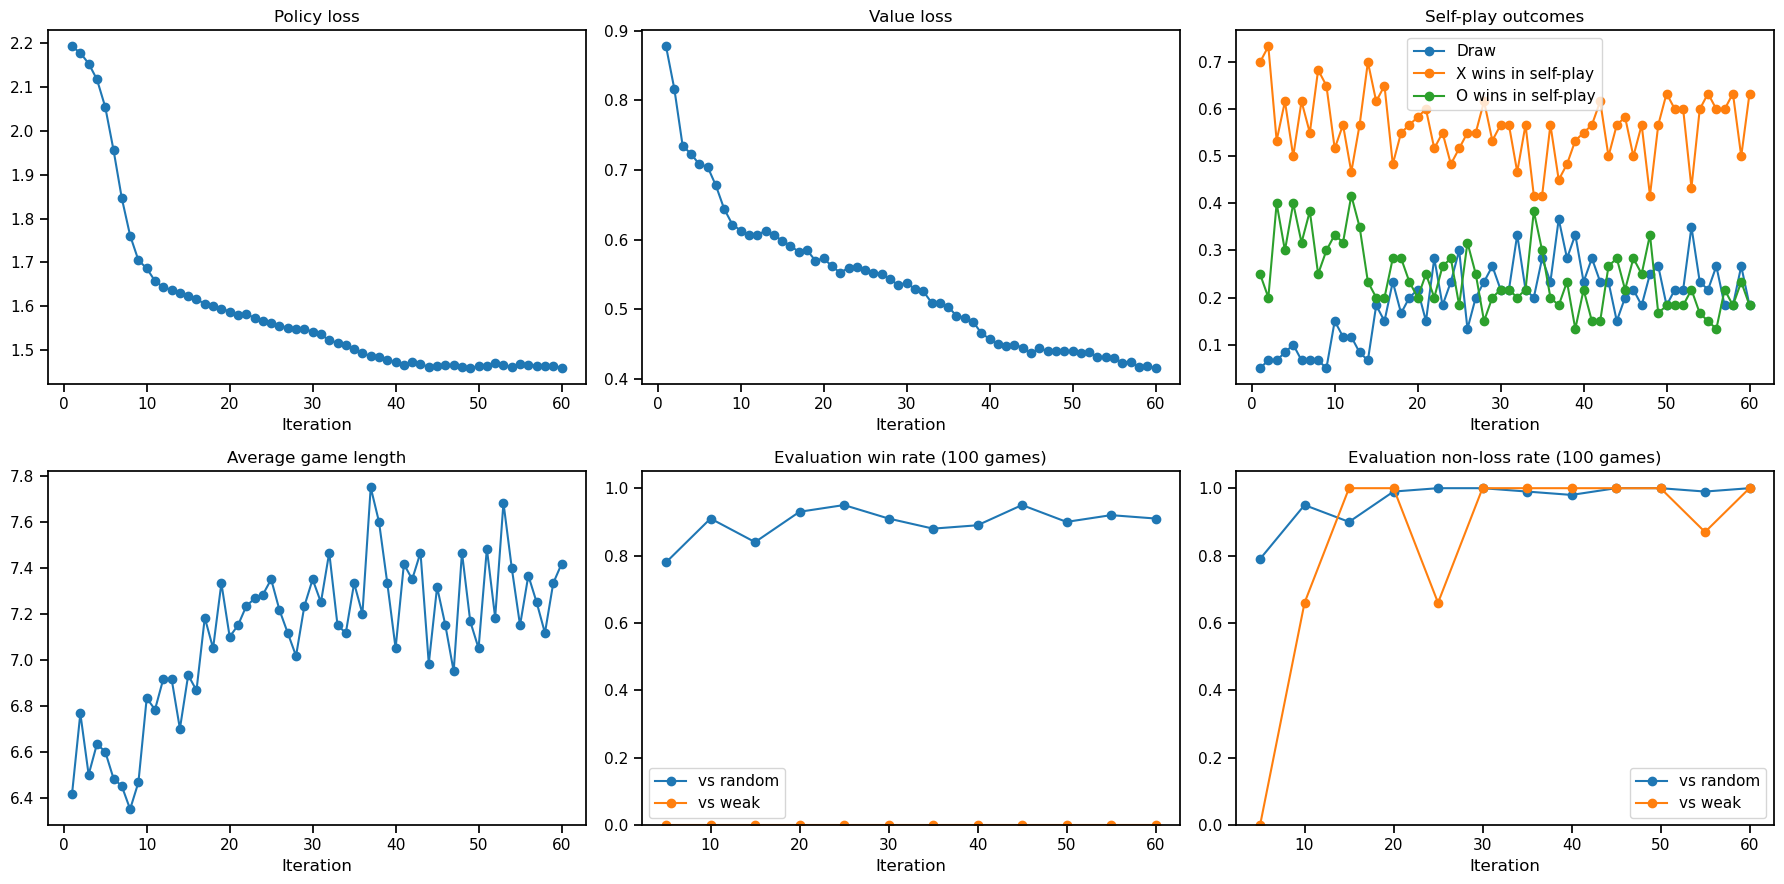

In [9]:

fig, axes = plt.subplots(2, 3, figsize=(18, 9))

axes[0, 0].plot(stats["iteration"], stats["policy_loss"], marker='o')
axes[0, 0].set_title("Policy loss")
axes[0, 0].set_xlabel("Iteration")

axes[0, 1].plot(stats["iteration"], stats["value_loss"], marker='o')
axes[0, 1].set_title("Value loss")
axes[0, 1].set_xlabel("Iteration")

axes[0, 2].plot(stats["iteration"], stats["draw_rate"], marker='o', label="Draw")
axes[0, 2].plot(stats["iteration"], stats["x_win_rate"], marker='o', label="X wins in self-play")
axes[0, 2].plot(stats["iteration"], stats["o_win_rate"], marker='o', label="O wins in self-play")
axes[0, 2].set_title("Self-play outcomes")
axes[0, 2].set_xlabel("Iteration")
axes[0, 2].legend()

axes[1, 0].plot(stats["iteration"], stats["avg_game_length"], marker='o')
axes[1, 0].set_title("Average game length")
axes[1, 0].set_xlabel("Iteration")

axes[1, 1].plot(stats["eval_iter"], stats["eval_win_rate_random"], marker='o', label="vs random")
axes[1, 1].plot(stats["eval_iter"], stats["eval_win_rate_weak"], marker='o', label="vs weak")
axes[1, 1].set_ylim(0, 1.05)
axes[1, 1].set_title("Evaluation win rate (100 games)")
axes[1, 1].set_xlabel("Iteration")
axes[1, 1].legend()

axes[1, 2].plot(stats["eval_iter"], stats["eval_non_loss_random"], marker='o', label="vs random")
axes[1, 2].plot(stats["eval_iter"], stats["eval_non_loss_weak"], marker='o', label="vs weak")
axes[1, 2].set_ylim(0, 1.05)
axes[1, 2].set_title("Evaluation non-loss rate (100 games)")
axes[1, 2].set_xlabel("Iteration")
axes[1, 2].legend()

plt.tight_layout()
plt.show()

## 9) Assessing the initial/mid/final checkpoints

This is a very visual way to see how the agent gets stronger in self-play.

In [10]:

def checkpoint_select_fn(checkpoint_model):
    checkpoint_model = checkpoint_model.to(device)
    checkpoint_model.eval()

    @torch.no_grad()
    def select(obs, legal_actions):
        logits, value = checkpoint_model(state_tensor(obs))
        probs, masked_logits = masked_policy_probs(logits, legal_actions, temperature=0.1)
        action = int(torch.argmax(masked_logits, dim=-1).item())
        return action, {"probs": probs.squeeze(0).cpu().numpy(), "value": float(value.item())}
    return select

for it in sorted(checkpoints.keys()):
    select_fn = checkpoint_select_fn(checkpoints[it])
    res_rand = evaluate_vs_opponent(select_fn, random_opponent_action, 100)
    res_weak = evaluate_vs_opponent(select_fn, weak_heuristic_action, 100)
    print(f"Checkpoint iteration {it}")
    print("  vs Random:", res_rand)
    print("  vs Weak  :", res_weak)
    print()

Checkpoint iteration 1
  vs Random: {'wins': 56, 'draws': 5, 'losses': 39, 'win_rate': 0.56, 'non_loss_rate': 0.61}
  vs Weak  : {'wins': 0, 'draws': 0, 'losses': 100, 'win_rate': 0.0, 'non_loss_rate': 0.0}

Checkpoint iteration 30
  vs Random: {'wins': 90, 'draws': 7, 'losses': 3, 'win_rate': 0.9, 'non_loss_rate': 0.97}
  vs Weak  : {'wins': 0, 'draws': 100, 'losses': 0, 'win_rate': 0.0, 'non_loss_rate': 1.0}

Checkpoint iteration 60
  vs Random: {'wins': 96, 'draws': 4, 'losses': 0, 'win_rate': 0.96, 'non_loss_rate': 1.0}
  vs Weak  : {'wins': 0, 'draws': 100, 'losses': 0, 'win_rate': 0.0, 'non_loss_rate': 1.0}



## 10) Comparing old checkpoints vs. new checkpoints

We'll have the final checkpoint play against an older checkpoint to see how self-play truly improves policy quality.

In [11]:

def play_model_vs_model(select_a, select_b, n_games=100):
    results = []
    for i in range(n_games):
        env = TicTacToeEnv()
        env.reset()
        player_a = 1 if (i % 2 == 0) else -1
        while not env.done:
            if env.current_player == player_a:
                obs = env._get_obs(player_a)
                action, _ = select_a(obs, env.legal_actions())
                env.step(action)
            else:
                obs = env._get_obs(-player_a)
                action, _ = select_b(obs, env.legal_actions())
                env.step(action)
        if env.winner == player_a:
            results.append(1)
        elif env.winner == 0:
            results.append(0)
        else:
            results.append(-1)
    return {
        "wins": sum(r == 1 for r in results),
        "draws": sum(r == 0 for r in results),
        "losses": sum(r == -1 for r in results),
        "win_rate": sum(r == 1 for r in results) / n_games,
        "non_loss_rate": sum(r >= 0 for r in results) / n_games,
    }

checkpoint_keys = sorted(checkpoints.keys())
if len(checkpoint_keys) >= 2:
    early_select = checkpoint_select_fn(checkpoints[checkpoint_keys[0]])
    mid_select = checkpoint_select_fn(checkpoints[checkpoint_keys[min(1, len(checkpoint_keys)-1)]])
    final_select = checkpoint_select_fn(checkpoints[checkpoint_keys[-1]])

    print("Final vs Early:", play_model_vs_model(final_select, early_select, 100))
    print("Final vs Mid  :", play_model_vs_model(final_select, mid_select, 100))

Final vs Early: {'wins': 100, 'draws': 0, 'losses': 0, 'win_rate': 1.0, 'non_loss_rate': 1.0}
Final vs Mid  : {'wins': 0, 'draws': 100, 'losses': 0, 'win_rate': 0.0, 'non_loss_rate': 1.0}


## 11) Heatmap policy and value on some sample boards

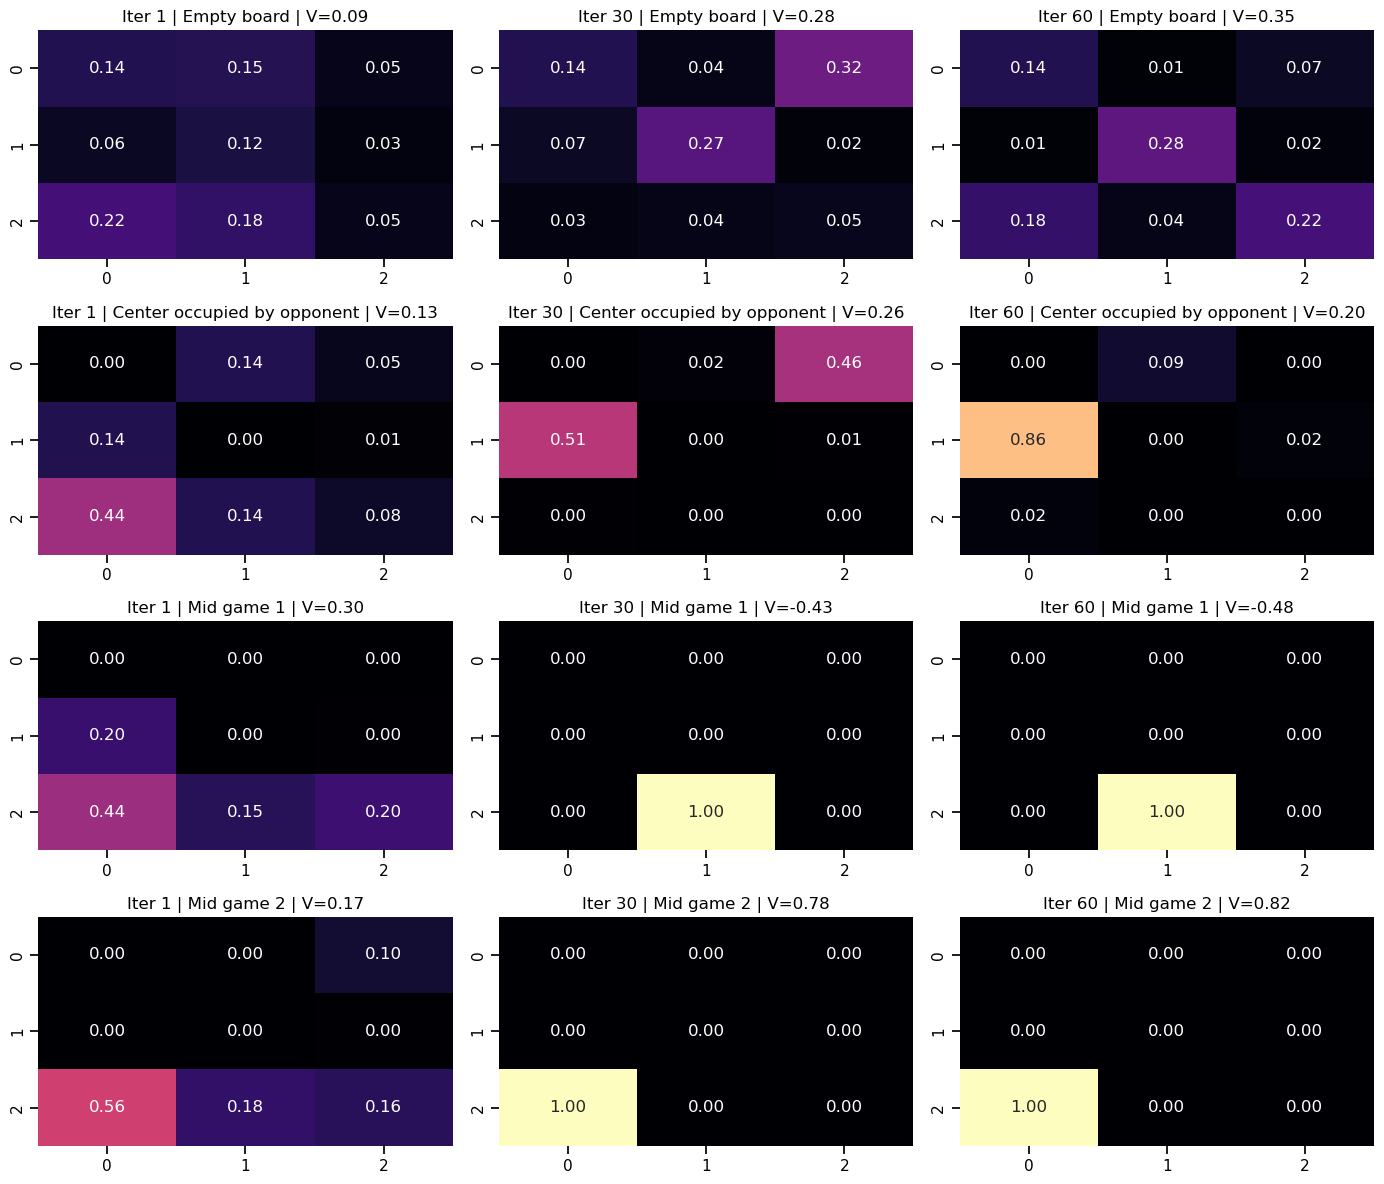

In [12]:

sample_states = [
    np.array([0,0,0,0,0,0,0,0,0], dtype=np.float32),
    np.array([1,0,0,0,-1,0,0,0,0], dtype=np.float32),
    np.array([1,-1,1,0,-1,0,0,0,0], dtype=np.float32),
    np.array([1,-1,0,1,-1,0,0,0,0], dtype=np.float32),
]

state_titles = ["Empty board", "Center occupied by opponent", "Mid game 1", "Mid game 2"]

@torch.no_grad()
def pv_outputs(model_like, state):
    legal = np.where(state == 0)[0].tolist()
    logits, value = model_like.to(device)(state_tensor(state))
    probs, _ = masked_policy_probs(logits, legal, temperature=0.1)
    return probs.squeeze(0).cpu().numpy(), float(value.item())

fig, axes = plt.subplots(len(sample_states), 3, figsize=(14, 3*len(sample_states)))
for i, (s, title) in enumerate(zip(sample_states, state_titles)):
    for j, ck in enumerate([1, 30, 60]):
        m = checkpoints[ck] if ck in checkpoints else model.cpu()
        probs, v = pv_outputs(m, s)
        sns.heatmap(probs.reshape(3,3), annot=True, fmt=".2f", cmap="magma", vmin=0, vmax=1,
                    cbar=False, ax=axes[i, j])
        axes[i, j].set_title(f"Iter {ck} | {title} | V={v:.2f}")
plt.tight_layout()
plt.show()

## 12) Replay a few matches with the final model

In [13]:

final_select = checkpoint_select_fn(checkpoints[max(checkpoints.keys())]) if checkpoints else checkpoint_select_fn(model.cpu())

for k in range(2):
    outcome, timeline = play_game_vs_opponent(final_select, weak_heuristic_action, agent_first=(k % 2 == 0), verbose=False)
    print("=" * 70)
    print(f"Replay {k+1} | outcome = {outcome}")
    print("=" * 70)
    for board, text, extras in timeline:
        print(text)
        print(render_board(board))
        if extras is not None:
            print("value =", round(extras["value"], 3))
            print("policy:")
            print(np.round(np.array(extras["probs"]).reshape(3,3), 2))
        print("-" * 20)

Replay 1 | outcome = 0
Agent->4
. . .
. X .
. . .
value = 0.35
policy:
[[0.14 0.01 0.07]
 [0.01 0.28 0.02]
 [0.18 0.04 0.22]]
--------------------
Opp->2
. . O
. X .
. . .
--------------------
Agent->5
. . O
. X X
. . .
value = 0.455
policy:
[[0.06 0.18 0.  ]
 [0.03 0.   0.6 ]
 [0.   0.   0.13]]
--------------------
Opp->3
. . O
O X X
. . .
--------------------
Agent->0
X . O
O X X
. . .
value = 0.727
policy:
[[0.96 0.04 0.  ]
 [0.   0.   0.  ]
 [0.   0.   0.  ]]
--------------------
Opp->8
X . O
O X X
. . O
--------------------
Agent->7
X . O
O X X
. X O
value = 0.231
policy:
[[0. 0. 0.]
 [0. 0. 0.]
 [0. 1. 0.]]
--------------------
Opp->1
X O O
O X X
. X O
--------------------
Agent->6
X O O
O X X
X X O
value = 0.138
policy:
[[0. 0. 0.]
 [0. 0. 0.]
 [1. 0. 0.]]
--------------------
Replay 2 | outcome = 0
Opp->4
. . .
. X .
. . .
--------------------
Agent->6
. . .
. X .
O . .
value = -0.651
policy:
[[0.01 0.02 0.11]
 [0.11 0.   0.03]
 [0.42 0.07 0.23]]
--------------------
Opp->0
X .